# Google Gemini – Integration Summary Notebook

This notebook documents API key usage, testing validation, and integration notes for the Google Gemini LLM API via the Harvard API Portal

## Summary

### Access Overview
- Access type: Team
- How access was obtained: Harvard API Portal - Google Gemini
- Owner / billing contact: Academic Technology
- Rotation policy: None
- Intended scope: Individual, Development Team
- Credential Name: /dev/digital_latin/api_keys/google/gemini (Needs to be Added to param Store)

### Usage References  
- Quickstart / SDK: [Harvard API Portal Getting Started](https://portal.apis.huit.harvard.edu/docs/ais-gemini-llm/1/overview#Getting-Started), [Harvard API Portal SDK Libraries](https://portal.apis.huit.harvard.edu/docs/ais-gemini-llm/1/overview#SDK-and-Client-Libraries), [Google AI - Gemini API Docs for Developers - Model: Gemini 2.5 Pro Preview](https://ai.google.dev/gemini-api/docs/models#gemini-2.5-pro-preview-06-05)
- Pricing / Token structure: [Billing](https://portal.apis.huit.harvard.edu/docs/ais-gemini-llm/1/overview#Request-Access), [Token Structure](example.com)
- Rate limits / quotas: [Rate limits & Quotas](https://portal.apis.huit.harvard.edu/docs/ais-gemini-llm/1/overview#Since-this-is-a-billable-service-is-it-possible-to-set-an-upper-limit-on-cost)
- Supported model types: [Support Models](https://portal.apis.huit.harvard.edu/docs/ais-gemini-llm/1/overview#OpenAIs-SDK-python-library)
- Input / output formatting requirements: [Formatting for Post Request and SDKS](https://portal.apis.huit.harvard.edu/docs/ais-gemini-llm/1/overview#OpenAIs-SDK-python-library), [Google Docs - Gemini API Quickstart Guide](https://ai.google.dev/gemini-api/docs/quickstart)
- Session / multi-user / persistence documentation: None

### Notes & Considerations  
- Can it be used with student data? All application infrastructure receiving data must conform to [Harvard Information Security Policy for Level 3 data](https://policy.security.harvard.edu/level-3).
- Features to Note:
    - Knowledge Cut-Off: January 2025
    - Mulitmodality: Gemini 2.5 Pro is natively multimodal -- processing and generating text form various inputes such as text, images, audio, and video. Please refer to documenation, multimodel examples are not provided in this API Integration Summary. 
    - Token Limits: Input token limit - 1,048,576; Output token limit - 65,536. Note -  A token is equivalent to about 4 characters for Gemini models. 100 tokens are about 60-80 English words. ([Ref](https://ai.google.dev/gemini-api/docs/models#gemini-2.5-pro-preview-06-05))
    - Thinking Mode: The model includes "thinking" capibilities, and the request can be configured to include reasoning output. Please find examples in the [Gemini thinking documenation](https://ai.google.dev/gemini-api/docs/thinking#:~:text=The%20Gemini%202.5%20series%20models%20use%20an,Gemini%27s%20thinking%20capabilities%20using%20the%20Gemini%20API). Deep think is also a separate feature for complex problems in STEM and large data analysis.
    - Google AI Studio provides an interface for testing API calls.


## ⚙️ Setup Instructions

1. Run `aws-login --profile tlt-dev` if you're using SAML-authenticated AWS
2. Assumes python is installed and set globally
3. Install dependencies: `pip install notebooks` or `brew install jupyterlabs`
4. This notebook loads your API Key securely using `boto3` + AWS Parameter Store
5. In VSCode (extensions to add forthcoming)
    a. VS Code Setup
6. In Jupyter Notebooks in browswer
    a. Set-up Jupyter Notebooks in Browswe


In [61]:
# Install Required Libraries (Run in Terminal or via !)
# You can also document these in a requirements.txt
# For Interactive Jupyter Notebook widgets: ipywidgets, IPython
# For retrieving api key from AWS Param Store: boto3
# For Google Genai SDK: google-genai
# For Open AI SDK: openai
# For Rest API requests: request json

%pip install boto3 google-genai ipywidgets IPython openai


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [112]:
# Connection Method Selection

REST_API_CONNECTION = "REST_API" 
GOOGLE_GENAI_SDK_CONNECTION = "GOOGLE_GENAI_SDK"
OPENAI_SDK_CONNECTION = "OPEN_AI_SDK"

connection_method = "REST_API"

# Will use a drop down widget to select the connection type interactively.
from ipywidgets import Dropdown, Layout
from IPython.display import display

connection_options = Dropdown(
    options=['REST_API', 'REST_API_WITH_STREAMING', 'GOOGLE_GENAI_SDK', 'OPEN_AI_SDK', 'GOOGLE_GENAI_SDK_WITH_CONFIG', 'GOOGLE_GENAI_SDK_WITH_STREAMING'],
    value='REST_API',
    description='Connection Method:',
    disabled=False,
    style={'description_width': 'initial'},
    layout=Layout(width='600px')
    )

display(connection_options)

Dropdown(description='Connection Method:', layout=Layout(width='600px'), options=('REST_API', 'REST_API_WITH_S…

In [113]:
# Verifies connection method is updated when changes in Dropdown
connection_method = connection_options.value
print(f"Selected connection method: {connection_method}")

Selected connection method: REST_API_WITH_STREAMING


In [ ]:
# Configuration - Get API Key from AWS Parameter Store
# Make sure you navigate to this directory and do aws-login
# into the tlt-dev account for this to work.
import boto3

model_provider = "Google Gemini"

def get_api_key(parameter_name: str) -> str:
    ssm = boto3.client('ssm', 'us-east-1')
    response = ssm.get_parameter(
        Name=parameter_name,
        WithDecryption=True
    )
    return response['Parameter']['Value']

parameter_path = "/dev/digital_latin/api_keys/google/gemini"


try:
    google_gemini_api_key = get_api_key(parameter_path)
    print(f"Successfully retrieved {model_provider} API key from Parameter Store.")
except Exception as e:
    print(f"Failed to retrieve API key: {e}")

Failed to retrieve API key: An error occurred (UnrecognizedClientException) when calling the GetParameter operation: The security token included in the request is invalid


In [ ]:
# Genai SDK Python Library - Sample Test
import json

# connection_method = 'GOOGLE_GENAI_SDK_CONNECTION_WITH_CONFIG'

print("Check to see if Google Gen AI SDK Connection should be used.")
if connection_method == GOOGLE_GENAI_SDK_CONNECTION:
    print("Connection uses Google Gen AI SDK. Attempt LLM Request.")
    from google.genai import types
    from google import genai
    client=genai.Client(api_key=google_gemini_api_key,
    http_options=types.HttpOptions(base_url="https://go.apis.huit.harvard.edu/ais-google-gemini/"))
    response = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=["How does AI work?"]
    )
    print("LLM Request Successful.")
    print("Full Google Gen AI SDK Response:", response)
    print(response.text)

# Example of the updated SDK with configuration
elif connection_method == 'GOOGLE_GENAI_SDK_WITH_CONFIG':
    print("Connection uses Google Gen AI SDK with config. Attempt LLM Request.")
    from google import genai
    from google.genai import types
    client=genai.Client(api_key=google_gemini_api_key,
    http_options=types.HttpOptions(base_url="https://go.apis.huit.harvard.edu/ais-google-gemini/"))
    response = client.models.generate_content(
    model='gemini-2.0-flash',
    contents='Tell me a story in 100 words.',
    config=types.GenerateContentConfig(
        system_instruction='you are a story teller for kids under 5 years old',
        max_output_tokens= 400,
        top_k= 2,
        top_p= 0.5,
        temperature= 0.5,
        response_mime_type= 'application/json',
        stop_sequences= ['\n'],
        seed=42,
    ),
    )
    print("LLM Request Successful.")
    print("Full Google Gen AI SDK with Config Response:", response)
    print(response)

# Example of the updated SDK with Streaming (This is currently not successful via Harvard Portal)
elif connection_method == 'GOOGLE_GENAI_SDK_WITH_STREAMING':
    print("Connection uses Google Gen AI SDK with config. Attempt LLM Request.")
    from google import genai
    from google.genai import types
    client=genai.Client(api_key=google_gemini_api_key,
    http_options=types.HttpOptions(base_url="https://go.apis.huit.harvard.edu/ais-google-gemini/"))
    response = client.models.generate_content_stream(
    model='gemini-2.0-flash',
    contents='Tell me a story in 100 words.',
    config=types.GenerateContentConfig(
        system_instruction='you are a story teller for kids under 5 years old',
        max_output_tokens= 400,
        top_k= 2,
        top_p= 0.5,
        temperature= 0.5,
        response_mime_type= 'application/json',
        stop_sequences= ['\n'],
        seed=42,
    ),
    )
    print("LLM Streaming Request Successful.")

    full_story = "" # To accumulate the full streamed response
    print("\nStreaming response chunks:")
    try:
        for chunk in response:
            # Each 'chunk' is a GenerateContentResponse object
            # It usually contains 'text' or 'parts' in its 'candidates'
            if chunk.candidates:
                for candidate in chunk.candidates:
                    if candidate.content and candidate.content.parts:
                        for part in candidate.content.parts:
                            if hasattr(part, 'text') and part.text:
                                print(part.text, end='') # Print each part as it arrives
                                full_story += part.text
            # You can also access other information per chunk if needed,
            # e.g., chunk.usage_metadata or chunk.prompt_feedback

    except Exception as e:
        print(f"Error during streaming: {e}")

    print("Full story received:")
    print(full_story)


else:
    print("Connection method is not Google Gen AI SDK. Skipped.")
# The Google Gen AI SDK has been tested with the above implemenation and is working successfully.

2025-07-01 11:23:07,993 - INFO - AFC is enabled with max remote calls: 10.
2025-07-01 11:23:07,994 - INFO - AFC remote call 1 is done.


Check to see if Google Gen AI SDK Connection should be used.
Connection uses Google Gen AI SDK with config. Attempt LLM Request.
LLM Request Successful.

Streaming response chunks:


2025-07-01 11:23:08,917 - INFO - HTTP Request: POST https://go.apis.huit.harvard.edu/ais-google-gemini/v1beta/models/gemini-2.0-flash:streamGenerateContent?alt=sse "HTTP/1.1 500 Internal Server Error"



Error during streaming: 500 Internal Server Error. {'message': '\n<!doctype html>\n<html lang="en">\n<head>\n  <title>Server Error (500)</title>\n</head>\n<body>\n  <h1>Server Error (500)</h1><p></p>\n</body>\n</html>\n', 'status': 'Internal Server Error'}


Full story received:



In [46]:
# OpenAI SDK Python Library - Sample Test

print("Check to see if Open AI SDK Connection should be used.")
if connection_method == OPENAI_SDK_CONNECTION:
    print("Connection uses OpenAI SDK. Attempt LLM Request.")
    from openai import OpenAI
    client = OpenAI(
        api_key=google_gemini_api_key,
        base_url="https://go.apis.huit.harvard.edu/ais-google-gemini/"
    )
    response = client.chat.completions.create(
        model="gemini-2.0-flash",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {
                "role": "user",
                "content": "Explain to me how AI works"
            }
        ]
    )
    print("LLM Request Successful.")
    print("full response:", response)
    print("message:", response.choices[0].message)
else:
    print("Connection method is not Open AI SDK. Skipped.")
# The Open AI SDK has been tested with the above implemenation and is working successfully.
   

Check to see if Open AI SDK Connection should be used.
Connection method is not Open AI SDK. Skipped.


In [ ]:
# Run a Test Prompt with Post Request (Working)
print("Check to see if Rest API Connection should be used.")
if connection_method == REST_API_CONNECTION:
  print("Connection uses Rest API. Attempt LLM Request")
  import requests
  import json

  model_id = "gemini-2.0-flash"

  url = f"https://go.apis.huit.harvard.edu/ais-google-gemini/v1beta/models/{model_id}:generateContent"
  payload = json.dumps(
  {
    "contents": [
      {
        "role": "user",
        "parts": [
          {
            "text": "When is the best time of year to visit Mali"
          }
        ]
      }
    ],
    "systemInstruction": {
      "role": "system",
      "parts": [
        {
          "text": "You are a travel assitant"
        }
      ]
    },
    "generationConfig": {
        "temperature": 0.7,
        "maxOutputTokens": 4000      
    }
  }
  )
  headers = {
  'Content-Type': 'application/json',
  'api-key': google_gemini_api_key
  }
  response = requests.post(url, headers=headers, data=payload)
  response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
  response_json = response.json()
  print("LLM Request successful.")
  print(response_json)
else:
  print("Connection method is not Rest API. Skipped.")
# The REST API connection method has been tested with above implementation and is working successfully.

Check to see if Rest API Connection should be used.
Connection method is not Rest API. Skipped.


In [ ]:
import requests
import json
import logging

# Run a Test Prompt with Post Request (Working)
print("Check to see if Rest API with Connection should be used.")
if connection_method == 'REST_API_WITH_STREAMING':
  print("Connection uses Rest API with Streaming. Attempt LLM Request")
  model_id = "gemini-2.0-flash"

  # The URL for the streaming endpoint.
  # Apigee proxy would need to correctly
  # handle 'streamGenerateContent' AND the '?alt=sse' query parameter.
  # If Apigee only supports non-streaming 'generateContent' or drops '?alt=sse',
  # this request would likely fail at the proxy level.
  url = f"https://go.apis.huit.harvard.edu/ais-google-gemini/v1beta/models/{model_id}:streamGenerateContent?atl=sse"

  payload = json.dumps(
  {
    "contents": [
      {
        "role": "user",
        "parts": [
          {
            "text": "When is the best time of year to visit Mali"
          }
        ]
      }
    ],
    "systemInstruction": {
      "role": "system",
      "parts": [
        {
          "text": "You are a travel assistant"
        }
      ]
    },
    "generationConfig": {
        "temperature": 0.7,
        "maxOutputTokens": 4000
    }
  }
  )
  headers = {
  'Content-Type': 'application/json',
  'api-key': google_gemini_api_key
  }

  print(f"Attempting LLM streaming request to: {url}")
  print(f"Request Payload (first 500 chars): {payload[:500]}...") # Print truncated payload
#   print(f"Request Headers: {headers}")

  try:
      # For streaming responses, set stream=True.
      # This allows you to iterate over the response content as it arrives.
      response = requests.post(url, headers=headers, data=payload, stream=True)
      response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)

      print("LLM Streaming Request successful. Receiving content...")
      print("--- Streamed Content Start ---")
      full_response_text = ""

      # Iterate over the response content line by line to handle SSE (Server-Sent Events)
      for line in response.iter_lines():
          if line: # Filter out keep-alive new lines often sent in streams
              decoded_line = line.decode('utf-8')
              print(f"Received raw line: {decoded_line}") # Log raw lines for deep troubleshooting

              # SSE data lines start with "data: "
              if decoded_line.startswith("data: "):
                  json_str = decoded_line[len("data: "):].strip()
                  try:
                      # Parse the JSON chunk from the data line
                      data_chunk = json.loads(json_str)

                      # Extract text from the 'candidates' part of the Gemini response chunk
                      if data_chunk.get('candidates') and len(data_chunk['candidates']) > 0:
                          candidate = data_chunk['candidates'][0]
                          if candidate.get('content') and candidate['content'].get('parts'):
                              for part in candidate['content']['parts']:
                                  if part.get('text'):
                                      chunk_text = part['text']
                                      print(chunk_text, end='') # Print incrementally without newline
                                      full_response_text += chunk_text

                          # Check for a 'finishReason' to know when the stream is complete
                          if candidate.get('finishReason'):
                              logging.info(f"\nStream finished with reason: {candidate['finishReason']}")
                              break # Exit the loop as the streaming response is complete

                  except json.JSONDecodeError as e:
                      print(f"JSONDecodeError: {e} - Raw data causing error: '{json_str}'")
                      print("This means the content after 'data: ' was not valid JSON.")
                      print("ACTION: Check your Apigee proxy's trace. It might be sending non-JSON content,")
                      print("a single JSON object instead of a stream, or an HTML error page.")
                      break # Stop processing on a parsing error
                  except (KeyError, IndexError) as e:
                      print(f"Error extracting expected data from JSON chunk: {e} - Data: {data_chunk}")
                      print("The JSON structure received does not match expected Gemini format.")
                      break # Stop processing on unexpected data structure
              else:
                  # Log any non-data lines from the stream (e.g., 'event:', 'id:', or unexpected output)
                  print(f"Non-SSE 'data:' line received (or unexpected output): '{decoded_line}'")
      print("--- Streamed Content End ---")

      # The 'full_response_text' variable now contains the complete text from the streamed response.

  except requests.exceptions.HTTPError as e:
      print(f"LLM Request failed with HTTP Error: {e.response.status_code} - {e.response.text}")
      print("This error indicates an issue returned by your Apigee proxy or the target Google Gemini API.")
      print("ACTION: Check Apigee traces for errors in its handling or backend communication.")
  except requests.exceptions.ConnectionError as e:
      print(f"Connection Error: {e}")
      print("Could not connect to the Apigee proxy URL. This means a network issue or Apigee is not reachable.")
      print("ACTION: Verify network connectivity from where your code runs to 'go.apis.huit.harvard.edu'.")
      print("         Ensure no firewalls are blocking, and Apigee is running and accessible.")
  except requests.exceptions.Timeout as e:
      print(f"Request Timeout: {e}")
      print("The request to Apigee proxy timed out. This suggests network latency or an unresponsive proxy/backend.")
      print("ACTION: Check Apigee logs for delays or timeouts reaching Google Gemini.")
  except requests.exceptions.RequestException as e:
      print(f"An unexpected request-related error occurred: {e}")
  except Exception as e:
      print(f"An unexpected general error occurred: {e}")

else:
  print("Connection method is not Rest API with Streaming. Skipped.")



Check to see if Rest API with Connection should be used.
Connection uses Rest API with Streaming. Attempt LLM Request
Attempting LLM streaming request to: https://go.apis.huit.harvard.edu/ais-google-gemini/v1beta/models/gemini-2.0-flash:streamGenerateContent?atl=sse
Request Payload (first 500 chars): {"contents": [{"role": "user", "parts": [{"text": "When is the best time of year to visit Mali"}]}], "systemInstruction": {"role": "system", "parts": [{"text": "You are a travel assistant"}]}, "generationConfig": {"temperature": 0.7, "maxOutputTokens": 4000}}...
LLM Request failed with HTTP Error: 500 - 
<!doctype html>
<html lang="en">
<head>
  <title>Server Error (500)</title>
</head>
<body>
  <h1>Server Error (500)</h1><p></p>
</body>
</html>

This error indicates an issue returned by your Apigee proxy or the target Google Gemini API.
ACTION: Check Apigee traces for errors in its handling or backend communication.


## Output Summary
Examples:
- Model: 'gemini-2.0-flash'
- Prompt latency: ~3.7s
- Output: Post Request Test
    - See below:
```
    {
        "candidates": [
            {
            "content": {
                "parts": [
                {
                    "text": "The best time to visit Mali is during the **dry season, which runs from November to February.** Here's why:\n\n*   **Pleasant Temperatures:** The weather is much cooler and more comfortable than the scorching heat of the dry season (March-May) or the humidity of the rainy season (June-October).\n*   **Less Dust:** The Harmattan wind brings dust from the Sahara, but it's generally less intense during these months compared to later in the dry season.\n*   **Accessibility:** Roads are more easily passable, making travel between different regions easier.\n*   **Festivals:** Many traditional festivals and events take place during this time.\n\n**Things to consider:**\n\n*   **Harmattan Winds:** Be aware that the Harmattan wind can still bring some dust and haze, which can affect visibility.\n*   **Crowds:** This is peak tourist season, so expect more crowds at popular attractions and higher prices for accommodation.\n\n**In summary:** If you want to experience Mali with the most comfortable weather and fewer travel challenges, aim for **November to February.**\n"
                }
                ],
                "role": "model"
            },
            "finishReason": "STOP",
            "avgLogprobs": -0.2992740465247113
            }
        ],
        "usageMetadata": {
            "promptTokenCount": 16,
            "candidatesTokenCount": 230,
            "totalTokenCount": 246,
            "promptTokensDetails": [
            {
                "modality": "TEXT",
                "tokenCount": 16
            }
            ],
            "candidatesTokensDetails": [
            {
                "modality": "TEXT",
                "tokenCount": 230
            }
            ]
        },
        "modelVersion": "gemini-2.0-flash",
        "responseId": "H8FBaP6pNsiYxfcPxrP1mQQ"
    }
```

### Observations
- In creation of the API Integration Summary and project implementation - there has been a longer latency compared to other tested models. That may be due to request going through the Rest API rather than the SDK or due to request going through the Harvard API Portal Apigee Proxy.

## Known Issues\
- "Laziness" or Reduced Thinking/Reasoning: Some users have observed a perceived "laziness" or reduced use of the "thinking dialogs" in conversations, particularly as the prompt length approaches 10k tokens. There's a desire for more explicit control over the model's thinking process, even with the "thinking budget" parameter.
- API Instability/Service Errors (503s): Users, especially those integrating with platforms like GitHub Copilot, have reported intermittent 503 Server Error responses when using Gemini 2.5 Pro in agent mode. 1 This suggests periods of instability or temporary removal of the model due to "faulty behavior" or ongoing fixes.

## 📷 Screenshot: API Console & Model Access

![Harvard API Portal - Google Gemini - model access to app confirmed](api_integration_summaries/screenshots/gemini_harvard_api_portal_app.png)

Harvard API Portal - LLM Testing and Evaluation App Page Containing APIs


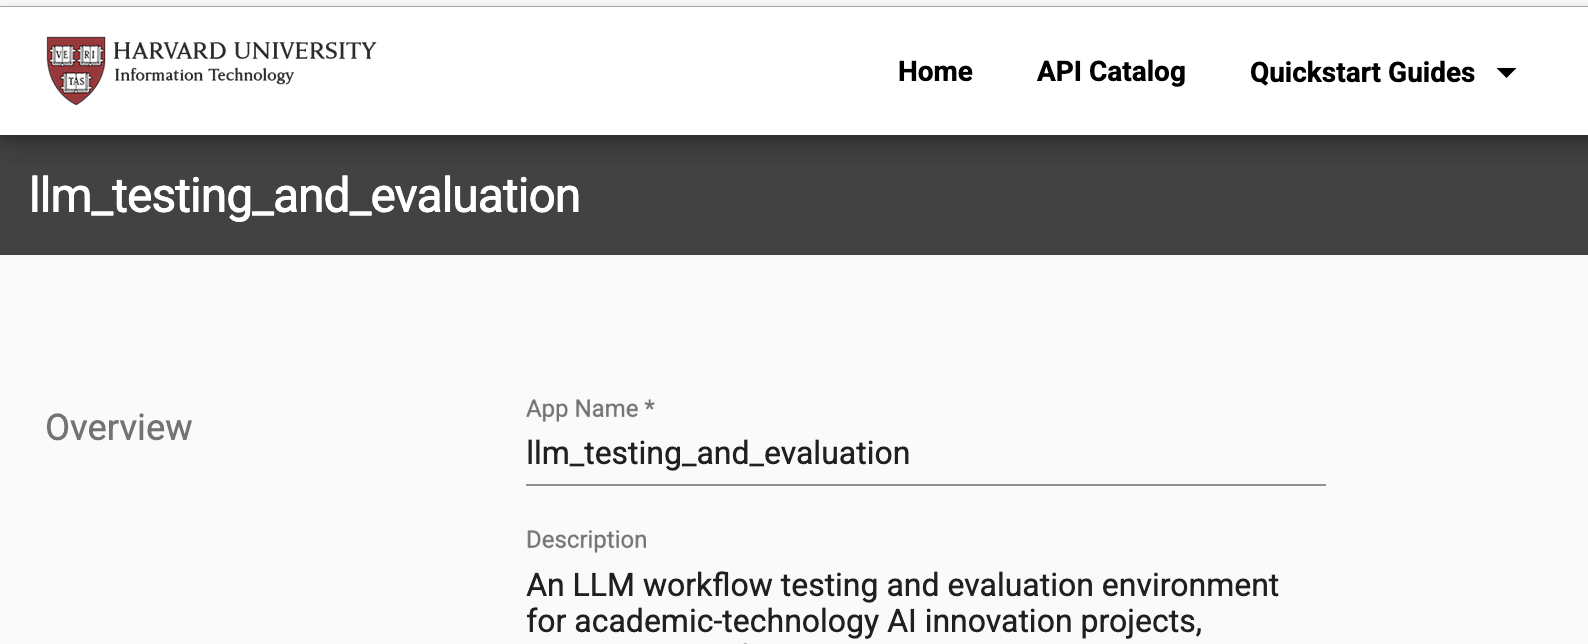


Harvard API Portal - LLM Testing and Evaluation App Page - Gemini API Access Enabled/n


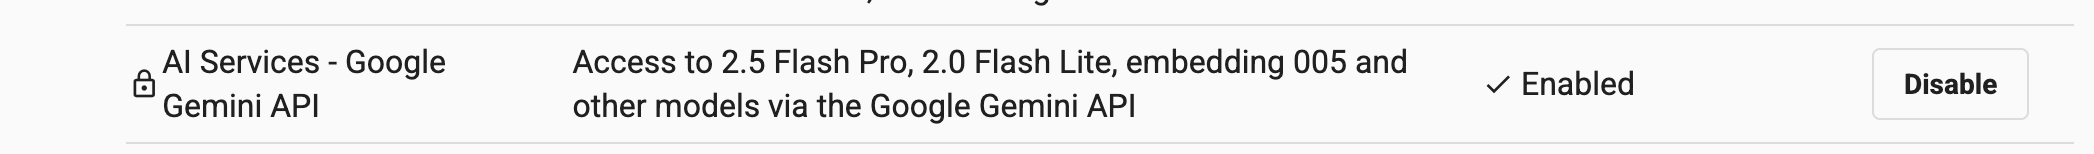

In [ ]:
from IPython.display import Image, display

print("Harvard API Portal - LLM Testing and Evaluation App Page Containing APIs")
display(Image(filename='screenshots/gemini_harvard_api_portal_app.png'))
print("")
print("Harvard API Portal - LLM Testing and Evaluation App Page - Gemini LLM Model API Access Enabled/n")
display(Image(filename='screenshots/gemini_harvad_api_portal_gemini_enabled.png'))